In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re

In [2]:
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

In [3]:
df = pd.read_csv('tugas_ganjil.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   MAL_ID     2000 non-null   int64 
 1   Name       2000 non-null   object
 2   Score      2000 non-null   object
 3   Genres     2000 non-null   object
 4   Episodes   2000 non-null   object
 5   Aired      2000 non-null   object
 6   Producers  2000 non-null   object
 7   Licensors  2000 non-null   object
 8   Studios    2000 non-null   object
 9   Duration   2000 non-null   object
 10  Rating     2000 non-null   object
dtypes: int64(1), object(10)
memory usage: 172.0+ KB


In [5]:
df.head()

,MAL_ID,Name,Score,Genres,Episodes,Aired,Producers,Licensors,Studios,Duration,Rating
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",26,"Apr 3, 1998 to Apr 24, 1999",Bandai Visual,"Funimation, Bandai Entertainment",Sunrise,24 min. per ep.,R - 17+ (violence & profanity)
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",1,"Sep 1, 2001","Sunrise, Bandai Visual",Sony Pictures Entertainment,Bones,1 hr. 55 min.,R - 17+ (violence & profanity)
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",26,"Apr 1, 1998 to Sep 30, 1998",Victor Entertainment,"Funimation, Geneon Entertainment USA",Madhouse,24 min. per ep.,PG-13 - Teens 13 or older
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",26,"Jul 2, 2002 to Dec 24, 2002","TV Tokyo, Bandai Visual, Dentsu, Victor Entert...","Funimation, Bandai Entertainment",Sunrise,25 min. per ep.,PG-13 - Teens 13 or older
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",52,"Sep 30, 2004 to Sep 29, 2005","TV Tokyo, Dentsu",Unknown,Toei Animation,23 min. per ep.,PG - Children


In [6]:
df.isnull().sum()

MAL_ID       0
Name         0
Score        0
Genres       0
Episodes     0
Aired        0
Producers    0
Licensors    0
Studios      0
Duration     0
Rating       0
dtype: int64

In [7]:
df['Score'] = pd.to_numeric(df['Score'], errors='coerce')

In [8]:
def clean_title(title):
    return re.sub(r'[^\w\s]', '', title).strip()

In [9]:
df['Name'] = df['Name'].apply(clean_title)

# Converting 'Genres' to a space-separated string for TF-IDF
df['Genres'] = df['Genres'].apply(lambda x: ' '.join(x.split(', ')))

# Creating a combined feature for content-based filtering
df['content'] = df['Name'] + ' ' + df['Genres']

# Handling 'Episodes' column for EDA (converting to numeric, handling 'Unknown')
df['Episodes'] = pd.to_numeric(df['Episodes'], errors='coerce')

In [10]:
df = df.reset_index(drop=True)

In [11]:
all_genres = []
for genres in df['Genres'].str.split():
    all_genres.extend(genres)
genre_counts = pd.Series(all_genres).value_counts()

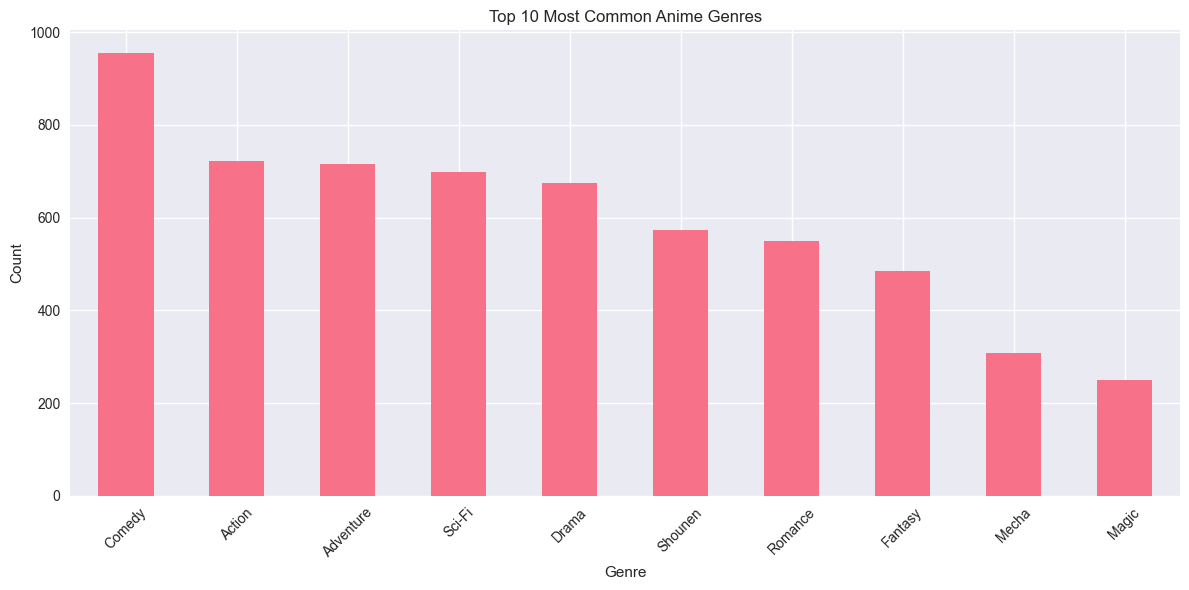

In [12]:
plt.figure(figsize=(12, 6))
genre_counts.head(10).plot(kind='bar')
plt.title('Top 10 Most Common Anime Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

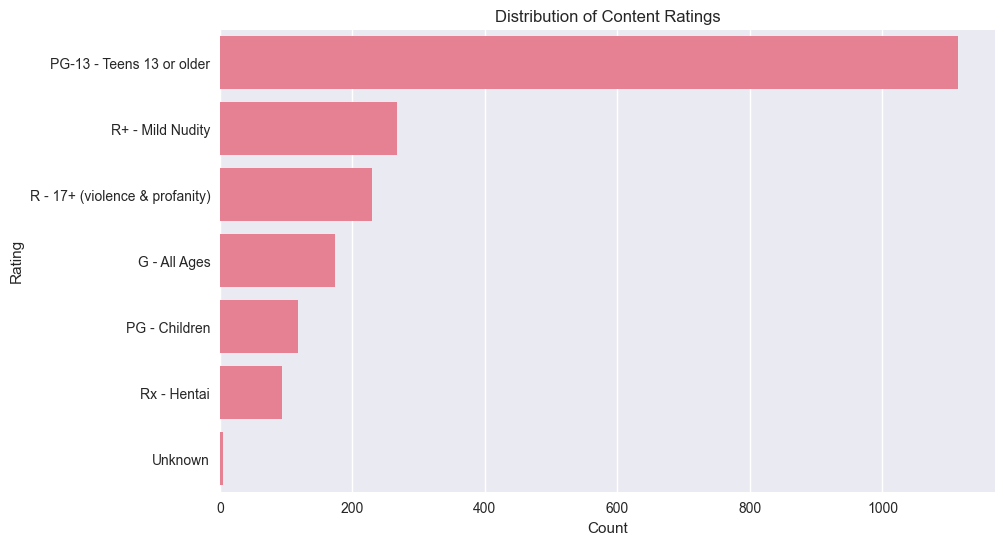

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(y='Rating', data=df, order=df['Rating'].value_counts().index)
plt.title('Distribution of Content Ratings')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.show()

In [14]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['content'])

In [15]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [17]:
def get_recommendations(title, cosine_sim=cosine_sim, df=df, num_recommendations=5):
    # Finding the index of the anime
    idx = df[df['Name'] == title].index
    if len(idx) == 0:
        return f"Anime '{title}' not found in the dataset."
    idx = idx[0]
    
    # Getting similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))
    # Sorting by similarity score
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    # Getting top recommendations (excluding the anime itself)
    sim_scores = sim_scores[1:num_recommendations+1]
    
    # Collecting recommended anime details
    anime_indices = [i[0] for i in sim_scores]
    recommendations = df[['Name', 'Genres', 'Score', 'Rating']].iloc[anime_indices].copy()
    # Ensure Score column in recommendations is numeric
    recommendations['Score'] = pd.to_numeric(recommendations['Score'], errors='coerce')
    
    # Debugging: Inspect Score column in recommendations
    print("\nRecommendations for '{}':".format(title))
    print("Recommendations Score Data Type:", recommendations['Score'].dtype)
    print("Recommendations Scores:", recommendations['Score'].tolist())
    
    recommendations['Similarity'] = [i[1] for i in sim_scores]
    
    return recommendations

In [18]:
sample_anime = 'Cowboy Bebop'
recommendations = get_recommendations(sample_anime, num_recommendations=5)
print(f"\nRecommendations for '{sample_anime}':")
recommendations


Recommendations for 'Cowboy Bebop':
Recommendations Score Data Type: float64
Recommendations Scores: [8.39, 5.81, 7.13, 7.45, 7.3]

Recommendations for 'Cowboy Bebop':


,Name,Genres,Score,Rating,Similarity
1,Cowboy Bebop Tengoku no Tobira,Action Drama Mystery Sci-Fi Space,8.39,R - 17+ (violence & profanity),0.704184
1471,Maps,Action Sci-Fi Adventure Space Comedy Shounen,5.81,R+ - Mild Nudity,0.266647
1266,Macross 7,Action Military Sci-Fi Adventure Music Space C...,7.13,PG-13 - Teens 13 or older,0.266513
1586,Freedom,Action Sci-Fi Adventure Space,7.45,PG-13 - Teens 13 or older,0.252315
990,Mobile Suit Gundam I,Action Military Sci-Fi Adventure Space Drama M...,7.30,PG-13 - Teens 13 or older,0.236302


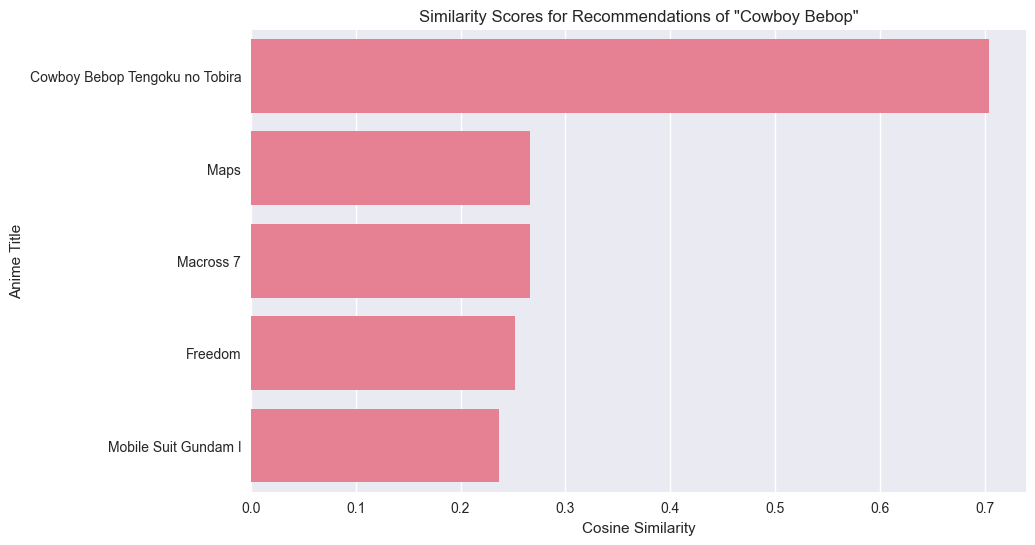

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Similarity', y='Name', data=recommendations)
plt.title(f'Similarity Scores for Recommendations of "{sample_anime}"')
plt.xlabel('Cosine Similarity')
plt.ylabel('Anime Title')
plt.show()

In [21]:
def evaluate_genre_overlap(input_anime, recommendations, df):
    input_genres = set(df[df['Name'] == input_anime]['Genres'].str.split().iloc[0])
    overlap_scores = []
    
    for _, row in recommendations.iterrows():
        rec_genres = set(row['Genres'].split())
        overlap = len(input_genres.intersection(rec_genres)) / len(input_genres)
        overlap_scores.append(overlap)
    
    return np.mean(overlap_scores)

In [22]:
overlap_score = evaluate_genre_overlap(sample_anime, recommendations, df)
print(f"\nAverage Genre Overlap for '{sample_anime}': {overlap_score:.2%}")


Average Genre Overlap for 'Cowboy Bebop': 80.00%


In [23]:
def evaluate_score_similarity(input_anime, recommendations, df):
    input_score = df[df['Name'] == input_anime]['Score'].iloc[0]
    
    # Debugging: Inspect input_score and recommendations scores
    print(f"\nEvaluating Score Similarity for '{input_anime}':")
    print(f"Input Score: {input_score}, Type: {type(input_score)}")
    print("Recommendation Scores:", recommendations['Score'].tolist())
    print("Recommendation Score Types:", recommendations['Score'].apply(type).tolist())
    
    score_diffs = []
    for _, row in recommendations.iterrows():
        if pd.isna(row['Score']):
            print(f"Warning: NaN Score found for {row['Name']}, skipping...")
            continue
        score_diff = abs(input_score - row['Score'])
        score_diffs.append(score_diff)
    
    if not score_diffs:
        return np.nan  # Return NaN if no valid scores
    return np.mean(score_diffs)

In [24]:
# Calculate score similarity for Cowboy Bebop
score_diff = evaluate_score_similarity(sample_anime, recommendations, df)
print(f"Average Score Difference for '{sample_anime}': {score_diff:.2f}")


Evaluating Score Similarity for 'Cowboy Bebop':
Input Score: 8.78, Type: <class 'numpy.float64'>
Recommendation Scores: [8.39, 5.81, 7.13, 7.45, 7.3]
Recommendation Score Types: [<class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>]
Average Score Difference for 'Cowboy Bebop': 1.56


In [25]:
test_anime = ['Cowboy Bebop', 'Naruto', 'One Piece']
overlap_scores = []
score_diffs = []

for anime in test_anime:
    recs = get_recommendations(anime, num_recommendations=5)
    if isinstance(recs, pd.DataFrame):
        print(f"\nRecommendations for '{anime}':")
        print(recs)
        
        # Genre overlap
        overlap = evaluate_genre_overlap(anime, recs, df)
        overlap_scores.append(overlap)
        
        # Score similarity
        score_diff = evaluate_score_similarity(anime, recs, df)
        if not np.isnan(score_diff):
            score_diffs.append(score_diff)


Recommendations for 'Cowboy Bebop':
Recommendations Score Data Type: float64
Recommendations Scores: [8.39, 5.81, 7.13, 7.45, 7.3]

Recommendations for 'Cowboy Bebop':
                                Name  \
1     Cowboy Bebop Tengoku no Tobira   
1471                            Maps   
1266                       Macross 7   
1586                         Freedom   
990             Mobile Suit Gundam I   

                                                 Genres  Score  \
1                     Action Drama Mystery Sci-Fi Space   8.39   
1471       Action Sci-Fi Adventure Space Comedy Shounen   5.81   
1266  Action Military Sci-Fi Adventure Music Space C...   7.13   
1586                      Action Sci-Fi Adventure Space   7.45   
990   Action Military Sci-Fi Adventure Space Drama M...   7.30   

                              Rating  Similarity  
1     R - 17+ (violence & profanity)    0.704184  
1471                R+ - Mild Nudity    0.266647  
1266       PG-13 - Teens 13 or older    

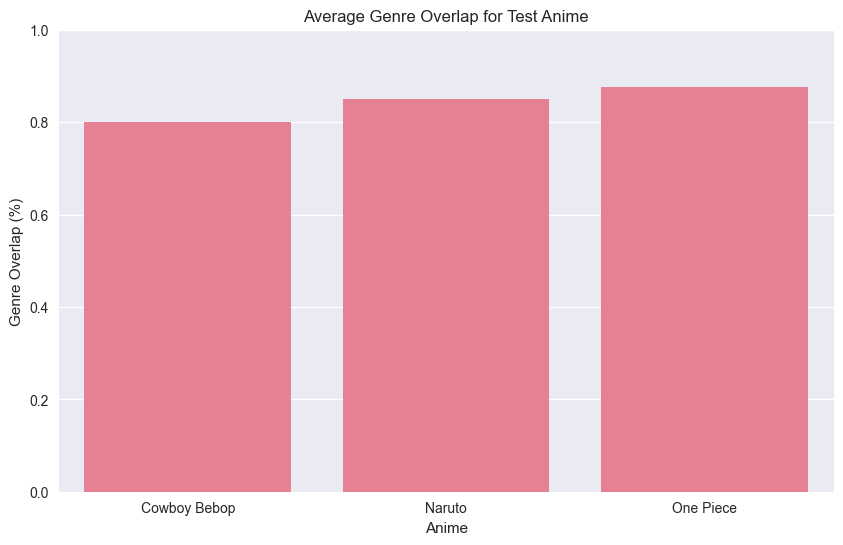

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(x=test_anime, y=overlap_scores)
plt.title('Average Genre Overlap for Test Anime')
plt.xlabel('Anime')
plt.ylabel('Genre Overlap (%)')
plt.ylim(0, 1)
plt.show()

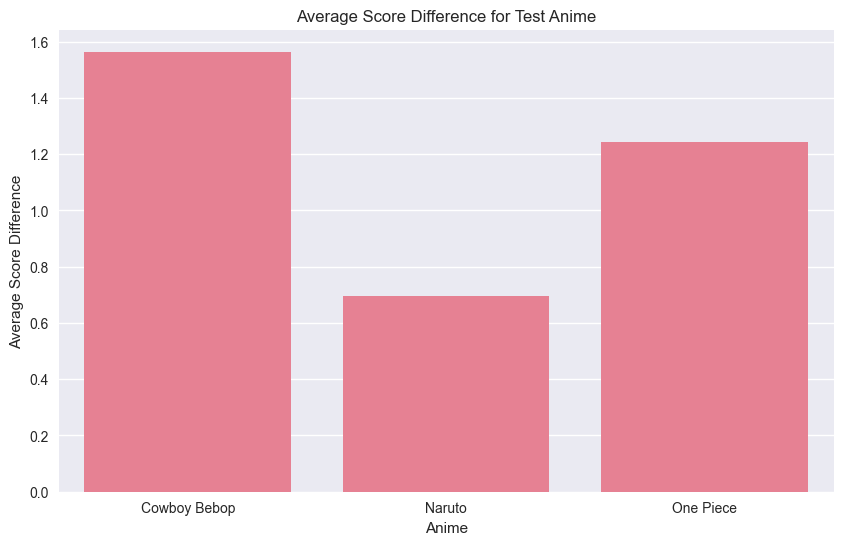

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(x=test_anime, y=score_diffs)
plt.title('Average Score Difference for Test Anime')
plt.xlabel('Anime')
plt.ylabel('Average Score Difference')
plt.show()

In [28]:
print(f"\nOverall Average Genre Overlap: {np.mean(overlap_scores):.2%}")
print(f"Overall Average Score Difference: {np.mean(score_diffs):.2f}")


Overall Average Genre Overlap: 84.17%
Overall Average Score Difference: 1.17
